In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf

In [ ]:
import torch
import os

# List of libraries to install
libraries = [
    'transformers',
    'pandas',
    'matplotlib',
    'Pillow',
    'bitsandbytes',
    'accelerate',
    'scipy',
    'einops',
    'sentencepiece',
    'xformers',
    'kagglehub'
]

# Conditionally install faiss-gpu or faiss-cpu
if torch.cuda.is_available():
    print("GPU detected. Installing faiss-gpu...")
    libraries.append('faiss-gpu')
else:
    print("No GPU detected. Installing faiss-cpu...")
    libraries.append('faiss-cpu')

# Install all libraries
for lib in libraries:
    os.system(f"pip install {lib}")

print("All specified libraries have been installed.")

GPU detected. Installing faiss-gpu...
All specified libraries have been installed.


In [ ]:
import os
import kagglehub
import pandas as pd

kaggle_dir = os.path.expanduser('~/.kaggle')
if not os.path.exists(kaggle_dir):
    os.makedirs(kaggle_dir)
    print(f"Created directory: {kaggle_dir}")

source_kaggle_json = '/content/kaggle.json'
dest_kaggle_json = os.path.join(kaggle_dir, 'kaggle.json')

# Only copy if the file exists and hasn't been copied yet
if os.path.exists(source_kaggle_json) and not os.path.exists(dest_kaggle_json):
    os.rename(source_kaggle_json, dest_kaggle_json)
    os.chmod(dest_kaggle_json, 0o600) # Set permissions
    print(f"Moved kaggle.json to {dest_kaggle_json} and set permissions.")
elif os.path.exists(dest_kaggle_json):
    print(f"kaggle.json already exists in {dest_kaggle_json}.")
else:
    print(f"Warning: kaggle.json not found at {source_kaggle_json}. Please upload it to /content/ and re-run this cell.")

# Download the dataset
print("Downloading 'Fashion Product Images (Small)' dataset...")
dataset_path = kagglehub.dataset_download('paramaggarwal/fashion-product-images-small')

print(f"Dataset downloaded to: {dataset_path}")



Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
Dataset downloaded to: /kaggle/input/fashion-product-images-small


In [ ]:
csv_file_path = os.path.join(dataset_path, 'styles.csv')
styles_df = pd.read_csv(csv_file_path, on_bad_lines='skip')

images_dir_path = os.path.join(dataset_path, 'images')

print("Styles DataFrame loaded successfully. Displaying the first 5 rows:")
display(styles_df.head())
print(f"Image directory path set to: {images_dir_path}")

Styles DataFrame loaded successfully. Displaying the first 5 rows:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


Image directory path set to: /kaggle/input/fashion-product-images-small/images


In [ ]:
print("Missing values before cleaning:")
print(styles_df.isnull().sum())

print("\nDuplicate rows before cleaning:")
print(styles_df.duplicated().sum())

Missing values before cleaning:
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

Duplicate rows before cleaning:
0


In [ ]:
styles_df['baseColour'].fillna('Unknown', inplace=True)
styles_df['season'].fillna('Unknown', inplace=True)
styles_df['usage'].fillna('Unknown', inplace=True)
styles_df['productDisplayName'].fillna('Unknown', inplace=True)

# Drop rows where 'year' is missing (only 1 row)
styles_df.dropna(subset=['year'], inplace=True)

print("Missing values after cleaning:")
print(styles_df.isnull().sum())

# Ensure 'year' is an integer type after dropping NaN
styles_df['year'] = styles_df['year'].astype(int)

Missing values after cleaning:
id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
dtype: int64


/tmp/ipykernel_23925/2957695511.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles_df['baseColour'].fillna('Unknown', inplace=True)
/tmp/ipykernel_23925/2957695511.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
styles_df['baseColour'].fillna('Unknown', inplace=True)
styles_df['season'].fillna('Unknown', inplace=True)
styles_df['usage'].fillna('Unknown', inplace=True)
styles_df['productDisplayName'].fillna('Unknown', inplace=True)

# Drop rows where 'year' is missing (only 1 row)
styles_df.dropna(subset=['year'], inplace=True)

print("Missing values after cleaning:")
print(styles_df.isnull().sum())

# Ensure 'year' is an integer type after dropping NaN
styles_df['year'] = styles_df['year'].astype(int)

# Select essential columns
essential_columns = [
    'id', 'masterCategory', 'subCategory', 'articleType',
    'gender', 'season', 'usage', 'productDisplayName'
]
processed_df = styles_df[essential_columns].copy()

# Validate image paths
processed_df['image_path'] = processed_df['id'].apply(lambda x: os.path.join(images_dir_path, str(x) + '.jpg'))

# Filter out rows where the image file does not exist
initial_rows = len(processed_df)
processed_df = processed_df[processed_df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"\nRemoved {initial_rows - len(processed_df)} entries due to missing image files.")
print("Processed DataFrame head:")
display(processed_df.head())
print("Processed DataFrame shape:", processed_df.shape)

/tmp/ipykernel_23925/2480509629.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles_df['baseColour'].fillna('Unknown', inplace=True)
/tmp/ipykernel_23925/2480509629.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

Missing values after cleaning:


/tmp/ipykernel_23925/2480509629.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles_df['usage'].fillna('Unknown', inplace=True)
/tmp/ipykernel_23925/2480509629.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
dtype: int64

Removed 5 entries due to missing image files.
Processed DataFrame head:


,id,masterCategory,subCategory,articleType,gender,season,usage,productDisplayName,image_path
0,15970,Apparel,Topwear,Shirts,Men,Fall,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/fashion-product-images-small/ima...
1,39386,Apparel,Bottomwear,Jeans,Men,Summer,Casual,Peter England Men Party Blue Jeans,/kaggle/input/fashion-product-images-small/ima...
2,59263,Accessories,Watches,Watches,Women,Winter,Casual,Titan Women Silver Watch,/kaggle/input/fashion-product-images-small/ima...
3,21379,Apparel,Bottomwear,Track Pants,Men,Fall,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/fashion-product-images-small/ima...
4,53759,Apparel,Topwear,Tshirts,Men,Summer,Casual,Puma Men Grey T-shirt,/kaggle/input/fashion-product-images-small/ima...


Processed DataFrame shape: (44418, 9)


In [ ]:
styles_df['baseColour'] = styles_df['baseColour'].fillna('Unknown')
styles_df['season'] = styles_df['season'].fillna('Unknown')
styles_df['usage'] = styles_df['usage'].fillna('Unknown')
styles_df['productDisplayName'] = styles_df['productDisplayName'].fillna('Unknown')

# Drop rows where 'year' is missing (only 1 row)
styles_df = styles_df.dropna(subset=['year'])

print("Missing values after cleaning:")
print(styles_df.isnull().sum())

# Ensure 'year' is an integer type after dropping NaN
styles_df['year'] = styles_df['year'].astype(int)

# Select essential columns
essential_columns = [
    'id', 'masterCategory', 'subCategory', 'articleType',
    'gender', 'season', 'usage', 'productDisplayName'
]
processed_df = styles_df[essential_columns].copy()

# Validate image paths
processed_df['image_path'] = processed_df['id'].apply(lambda x: os.path.join(images_dir_path, str(x) + '.jpg'))

# Filter out rows where the image file does not exist
initial_rows = len(processed_df)
processed_df = processed_df[processed_df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"\nRemoved {initial_rows - len(processed_df)} entries due to missing image files.")
print("Processed DataFrame head:")
display(processed_df.head())
print("Processed DataFrame shape:", processed_df.shape)

Missing values after cleaning:
id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
dtype: int64

Removed 5 entries due to missing image files.
Processed DataFrame head:


,id,masterCategory,subCategory,articleType,gender,season,usage,productDisplayName,image_path
0,15970,Apparel,Topwear,Shirts,Men,Fall,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/fashion-product-images-small/ima...
1,39386,Apparel,Bottomwear,Jeans,Men,Summer,Casual,Peter England Men Party Blue Jeans,/kaggle/input/fashion-product-images-small/ima...
2,59263,Accessories,Watches,Watches,Women,Winter,Casual,Titan Women Silver Watch,/kaggle/input/fashion-product-images-small/ima...
3,21379,Apparel,Bottomwear,Track Pants,Men,Fall,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/fashion-product-images-small/ima...
4,53759,Apparel,Topwear,Tshirts,Men,Summer,Casual,Puma Men Grey T-shirt,/kaggle/input/fashion-product-images-small/ima...


Processed DataFrame shape: (44418, 9)


In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch
from PIL import Image
import os

# 1. Initialize the BLIP processor and model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# 2. Move the model to the appropriate device
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"BLIP model loaded and moved to device: {device}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP model loaded and moved to device: cuda


In [ ]:
import tqdm

batch_size = 32  # You can adjust this based on your available memory

captions = []
image_ids = []

print(f"Generating captions for {len(processed_df)} images...")

# 4. Generate captions in batches
for i in tqdm.tqdm(range(0, len(processed_df), batch_size), desc="Generating Captions"):
    batch_df = processed_df.iloc[i:i + batch_size]
    batch_images = []
    batch_image_ids = []

    for idx, row in batch_df.iterrows():
        try:
            img_path = row['image_path']
            image = Image.open(img_path).convert("RGB")
            batch_images.append(image)
            batch_image_ids.append(row['id'])
        except Exception as e:
            print(f"Error loading image {row['id']}: {e}")
            continue

    if not batch_images:
        continue

    # Preprocess images
    inputs = processor(images=batch_images, return_tensors="pt").to(device)

    # Generate captions
    with torch.no_grad(): # Disable gradient calculation for inference
        generated_ids = model.generate(**inputs, max_new_tokens=50)
    generated_captions = processor.batch_decode(generated_ids, skip_special_tokens=True)

    captions.extend(generated_captions)
    image_ids.extend(batch_image_ids)

# 5. Create a DataFrame for captions and save to CSV
captions_df = pd.DataFrame({'id': image_ids, 'caption': captions})
captions_df.to_csv('captions.csv', index=False)

print("\nCaption generation complete.")
print("First 5 generated captions:")
display(captions_df.head())
print(f"Captions saved to captions.csv. Total captions: {len(captions_df)}")


Generating captions for 44418 images...


Generating Captions:   0%|          | 1/1389 [00:04<1:39:04,  4.28s/it]


KeyboardInterrupt: 

In [ ]:
import tqdm

import os

captions_filepath = 'captions.csv'

# Load existing captions if the file exists, otherwise start fresh
if os.path.exists(captions_filepath):
    existing_captions_df = pd.read_csv(captions_filepath)
    existing_image_ids = set(existing_captions_df['id'].tolist())

    # Filter processed_df to only include images that don't have captions yet
    images_to_caption_df = processed_df[~processed_df['id'].isin(existing_image_ids)].reset_index(drop=True)

    all_captions = existing_captions_df['caption'].tolist()
    all_image_ids = existing_captions_df['id'].tolist()
    print(f"Resuming caption generation. {len(existing_image_ids)} captions already exist.")
    print(f"Need to generate captions for {len(images_to_caption_df)} new images.")
else:
    images_to_caption_df = processed_df.copy()
    all_captions = []
    all_image_ids = []
    print(f"No existing captions. Generating captions for all {len(images_to_caption_df)} images.")

# Define batch processing parameters
batch_size = 32  # You can adjust this based on your available memory

print(f"Generating captions for {len(images_to_caption_df)} images...")

# Generate captions in batches for the remaining images
for i in tqdm.tqdm(range(0, len(images_to_caption_df), batch_size), desc="Generating Captions"):
    batch_df = images_to_caption_df.iloc[i:i + batch_size]
    batch_images = []
    batch_image_ids = []

    for idx, row in batch_df.iterrows():
        try:
            img_path = row['image_path']
            image = Image.open(img_path).convert("RGB")
            batch_images.append(image)
            batch_image_ids.append(row['id'])
        except FileNotFoundError:
            print(f"Warning: Image file not found for ID {row['id']} at {img_path}. Skipping.")
            continue
        except Exception as e:
            print(f"Error loading image {row['id']} from {img_path}: {e}. Skipping.")
            continue

    if not batch_images:
        continue

    # Preprocess images
    # Ensure 'processor' and 'model' from previous cell (0935d2fa) are available
    inputs = processor(images=batch_images, return_tensors="pt").to(device)

    # Generate captions
    with torch.no_grad(): # Disable gradient calculation for inference
        generated_ids = model.generate(**inputs, max_new_tokens=50)
    generated_captions = processor.batch_decode(generated_ids, skip_special_tokens=True)

    all_captions.extend(generated_captions)
    all_image_ids.extend(batch_image_ids)

# Create a DataFrame for all captions and save to CSV
captions_df = pd.DataFrame({'id': all_image_ids, 'caption': all_captions})
captions_df.to_csv(captions_filepath, index=False)

print("\nCaption generation complete.")
print("First 5 generated captions (from the full list):")
display(captions_df.head())
print(f"Captions saved to {captions_filepath}. Total captions: {len(captions_df)}")

Resuming caption generation. 44418 captions already exist.
Need to generate captions for 0 new images.
Generating captions for 0 images...


Generating Captions: 0it [00:00, ?it/s]



Caption generation complete.
First 5 generated captions (from the full list):


,id,caption
0,15970,a man in a plaid shirt and jeans
1,39386,a man in a grey shirt and jeans
2,59263,a white watch with a silver band
3,21379,a man in a red shirt and black pants
4,53759,a man in a blue polo shirt and jeans


Captions saved to captions.csv. Total captions: 44418


In [ ]:
from transformers import CLIPProcessor, CLIPModel

# 1. Initialize the CLIP processor and model
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

# 2. Move the model to the appropriate device
# device is already defined from BLIP model initialization
clip_model.to(device)

print(f"CLIP model loaded and moved to device: {device}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP model loaded and moved to device: cuda


In [ ]:
import numpy as np

# 3. Define batch processing parameters for CLIP
# Using the same batch_size as BLIP for consistency, adjust if needed
# batch_size is already defined from BLIP model initialization

image_embeddings = []
embedding_image_ids = []

print(f"Generating CLIP embeddings for {len(processed_df)} images...")

# 4. Generate embeddings in batches
for i in tqdm.tqdm(range(0, len(processed_df), batch_size), desc="Generating CLIP Embeddings"):
    batch_df = processed_df.iloc[i:i + batch_size]
    batch_images = []
    batch_ids = []

    for idx, row in batch_df.iterrows():
        try:
            img_path = row['image_path']
            image = Image.open(img_path).convert("RGB")
            batch_images.append(image)
            batch_ids.append(row['id'])
        except Exception as e:
            print(f"Error loading image {row['id']}: {e}")
            continue

    if not batch_images:
        continue

    # Preprocess images using CLIP processor
    clip_inputs = clip_processor(images=batch_images, return_tensors="pt").to(device)

    # Generate embeddings
    with torch.no_grad():
        # The error indicates that clip_model.get_image_features might be returning a
        # BaseModelOutputWithPooling object instead of a direct tensor.
        # We need to extract the actual tensor from this output object.
        raw_clip_output = clip_model.get_image_features(**clip_inputs)

        # Check if the output is a BaseModelOutputWithPooling and extract the pooled output
        if hasattr(raw_clip_output, 'pooler_output'):
            embeddings = raw_clip_output.pooler_output
        elif hasattr(raw_clip_output, 'image_embeds'): # In case it's CLIPOutput or similar with 'image_embeds'
            embeddings = raw_clip_output.image_embeds
        elif isinstance(raw_clip_output, torch.Tensor):
            embeddings = raw_clip_output # It's already a tensor, as expected by documentation
        else:
            # Fallback or raise an error if the type is completely unexpected
            raise TypeError(f"Unexpected return type for CLIP embeddings: {type(raw_clip_output)}. Expected torch.Tensor or a model output object with 'pooler_output'/'image_embeds'.")

    # Normalize embeddings (important for cosine similarity)
    normalized_embeddings = embeddings / embeddings.norm(p=2, dim=-1, keepdim=True)

    image_embeddings.append(normalized_embeddings.cpu().numpy())
    embedding_image_ids.extend(batch_ids)

# Concatenate all embeddings into a single NumPy array
image_embeddings_np = np.concatenate(image_embeddings, axis=0)

# Create a DataFrame for image IDs and embeddings, then save
embeddings_df = pd.DataFrame({'id': embedding_image_ids})
# Store embeddings as a list of floats (or convert to string for CSV if necessary)
# For better efficiency and direct usage with FAISS, saving as a numpy file is often preferred
np.save('image_embeddings.npy', image_embeddings_np)
embeddings_df['embedding_idx'] = range(len(embeddings_df))
embeddings_df.to_csv('image_embeddings_metadata.csv', index=False)

print("\nCLIP embedding generation complete.")
print(f"Embeddings saved to image_embeddings.npy. Shape: {image_embeddings_np.shape}")
print(f"Embedding metadata saved to image_embeddings_metadata.csv. Total embeddings: {len(embeddings_df)}")

Generating CLIP embeddings for 44418 images...


Generating CLIP Embeddings:   2%|▏         | 33/1389 [00:07<04:49,  4.69it/s]


KeyboardInterrupt: 

In [ ]:
import faiss

# 1. Load the generated CLIP embeddings and their metadata
image_embeddings_np = np.load('image_embeddings.npy')
embeddings_df = pd.read_csv('image_embeddings_metadata.csv')

# Ensure the order of embeddings matches the DataFrame if not already done
# Assuming image_embeddings_np and embeddings_df['id'] are in the same order

embedding_dim = image_embeddings_np.shape[1] # Dimension of the embeddings

print(f"Loaded image embeddings with shape: {image_embeddings_np.shape}")
print(f"Embedding dimension: {embedding_dim}")

Loaded image embeddings with shape: (44418, 512)
Embedding dimension: 512


In [ ]:
# 2. Initialize FAISS index
# We'll use IndexFlatL2 for a simple L2 distance based search.
# For very large datasets, more advanced indices like IndexIVFFlat might be considered.
index = faiss.IndexFlatL2(embedding_dim)

# 3. Add embeddings to the index
# FAISS requires float32 data type
index.add(image_embeddings_np.astype('float32'))

print(f"FAISS index created with {index.ntotal} vectors.")

FAISS index created with 44418 vectors.


In [ ]:
# 4. Save the FAISS index to disk
faiss.write_index(index, 'faiss_index.bin')

print("FAISS index saved to faiss_index.bin")

# 5. Merge processed_df with embedding metadata for complete product information
# This step ensures that we can easily retrieve product metadata given an embedding index.
final_products_df = pd.merge(processed_df, embeddings_df, on='id', how='inner')

print("\nMerged product metadata with embedding IDs. First 5 rows:")
display(final_products_df.head())
print(f"Final products DataFrame shape: {final_products_df.shape}")

# Save the final DataFrame for future use
final_products_df.to_csv('final_products.csv', index=False)
print("Final products DataFrame saved to final_products.csv")

FAISS index saved to faiss_index.bin

Merged product metadata with embedding IDs. First 5 rows:


,id,masterCategory,subCategory,articleType,gender,season,usage,productDisplayName,image_path,embedding_idx
0,15970,Apparel,Topwear,Shirts,Men,Fall,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/fashion-product-images-small/ima...,0
1,39386,Apparel,Bottomwear,Jeans,Men,Summer,Casual,Peter England Men Party Blue Jeans,/kaggle/input/fashion-product-images-small/ima...,1
2,59263,Accessories,Watches,Watches,Women,Winter,Casual,Titan Women Silver Watch,/kaggle/input/fashion-product-images-small/ima...,2
3,21379,Apparel,Bottomwear,Track Pants,Men,Fall,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/fashion-product-images-small/ima...,3
4,53759,Apparel,Topwear,Tshirts,Men,Summer,Casual,Puma Men Grey T-shirt,/kaggle/input/fashion-product-images-small/ima...,4


Final products DataFrame shape: (44418, 10)
Final products DataFrame saved to final_products.csv


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

LLM_NAME = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)

llm = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Qwen Loaded Successfully!")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Qwen Loaded Successfully!


In [ ]:
from sentence_transformers import SentenceTransformer

# Initialize a SentenceTransformer model for text embeddings
text_model = SentenceTransformer('all-MiniLM-L6-v2')

print("SentenceTransformer (text_model) loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer (text_model) loaded successfully!


In [ ]:
import faiss

# Generate text embeddings for all product display names
product_names = final_products_df['productDisplayName'].tolist()
text_embeddings_np = text_model.encode(product_names, convert_to_numpy=True, normalize_embeddings=True)

# Save the text embeddings to disk
np.save('text_embeddings.npy', text_embeddings_np)

# Initialize a FAISS index for text embeddings
text_embedding_dim = text_embeddings_np.shape[1]
text_index = faiss.IndexFlatL2(text_embedding_dim)

# Add text embeddings to the FAISS index
text_index.add(text_embeddings_np.astype('float32'))

print(f"FAISS text index created with {text_index.ntotal} vectors.")

FAISS text index created with 44418 vectors.


In [ ]:
def recommend_from_uploaded_image(image_path, top_k=4):

    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(images=image,
                            return_tensors="pt").to(device)

    with torch.no_grad():
        raw_clip_output = clip_model.get_image_features(**inputs)

    # Extract the actual embedding tensor from the model output object
    if hasattr(raw_clip_output, 'pooler_output'):
        image_embedding = raw_clip_output.pooler_output
    elif hasattr(raw_clip_output, 'image_embeds'): # In case it's CLIPOutput or similar with 'image_embeds'
        image_embedding = raw_clip_output.image_embeds
    elif isinstance(raw_clip_output, torch.Tensor):
        image_embedding = raw_clip_output # It's already a tensor, as expected by documentation
    else:
        raise TypeError(f"Unexpected return type for CLIP embeddings: {type(raw_clip_output)}. Expected torch.Tensor or a model output object with 'pooler_output'/'image_embeds'.")

    image_embedding = image_embedding / image_embedding.norm(dim=-1, keepdim=True)
    image_embedding = image_embedding.cpu().numpy().astype(np.float32)

    D, I = index.search(image_embedding, 1)

    matched_product = final_products_df.iloc[I[0][0]]

    print("Matched Product")
    print(matched_product["productDisplayName"])

    prompt = f"""
You are a professional fashion stylist.

Customer uploaded an image.

Detected Product:

Product Name:
{matched_product['productDisplayName']}

Category:
{matched_product['articleType']}

Gender:
{matched_product['gender']}

Usage:
{matched_product['usage']}

Suggest {top_k} complementary fashion items.

Return only comma-separated list.
"""

    messages = [{"role":"user","content":prompt}]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text,
                       return_tensors="pt").to(llm.device)

    outputs = llm.generate(
        **inputs,
        max_new_tokens=80,
        temperature=0.7
    )

    response = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

    print(response)

    queries = [x.strip() for x in response.split(",")]

    recommendations = []

    for q in queries:

        embedding = text_model.encode(
            q,
            normalize_embeddings=True
        )

        D,I = text_index.search(
            np.array([embedding],dtype=np.float32),
            1
        )

        recommendations.append(
            final_products_df.iloc[I[0][0]]
        )

    fig,axes = plt.subplots(
        1,
        len(recommendations)+2,
        figsize=(25,6)
    )

    axes[0].imshow(image)
    axes[0].set_title("Uploaded Image")
    axes[0].axis("off")

    axes[1].imshow(Image.open(matched_product.image_path))
    axes[1].set_title("Matched Product")
    axes[1].axis("off")
    for i,rec in enumerate(recommendations):

        axes[i+2].imshow(Image.open(rec.image_path))
        axes[i+2].set_title(rec.articleType)
        axes[i+2].axis("off")

    plt.tight_layout()
    plt.show()

    return recommendations

In [ ]:
def get_random_image_path(df):
    """
    Selects a random image path from the DataFrame.
    """
    random_product = df.sample(n=1).iloc[0]
    return random_product['image_path']

Using random image: /kaggle/input/fashion-product-images-small/images/41551.jpg
Matched Product
Lee Cooper Men Black Formal Shoes
Tuxedo Suit, White Shirt, Bow Tie, Dress Slacks


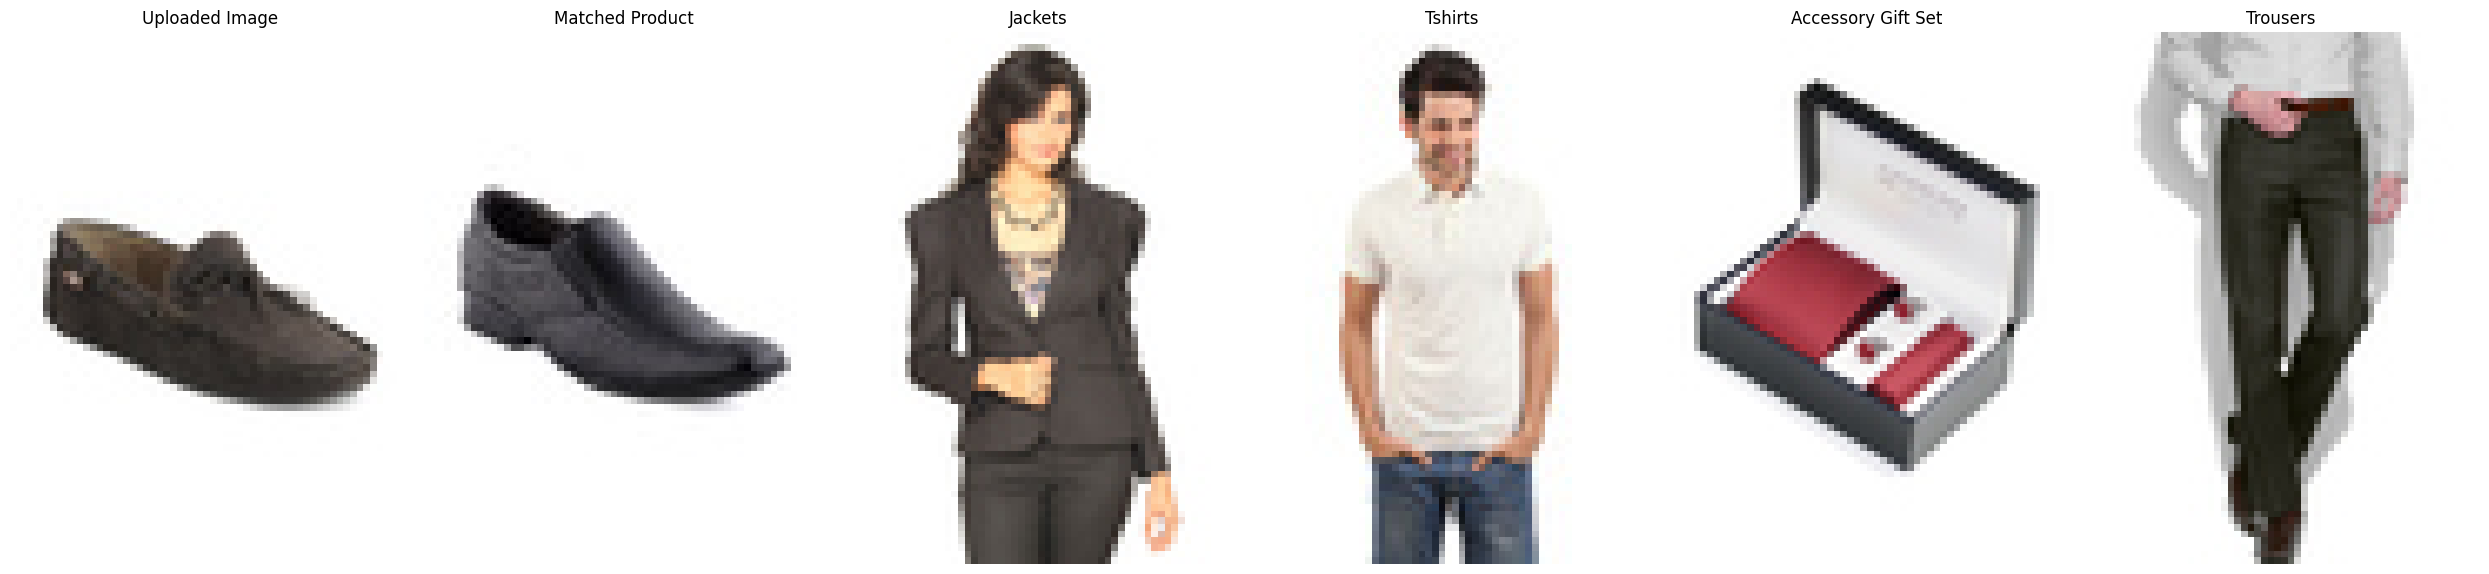

[id                                                                 6886
 masterCategory                                                  Apparel
 subCategory                                                     Topwear
 articleType                                                     Jackets
 gender                                                            Women
 season                                                           Summer
 usage                                                            Casual
 productDisplayName       Forever New Women Puff Sleeve Tux Black Jacket
 image_path            /kaggle/input/fashion-product-images-small/ima...
 embedding_idx                                                      3255
 Name: 3255, dtype: object,
 id                                                                29787
 masterCategory                                                  Apparel
 subCategory                                                     Topwear
 articleType           

In [ ]:
# Get a random image path
random_image_path = get_random_image_path(final_products_df)
print(f"Using random image: {random_image_path}")

# Call the recommendation function with the random image
recommend_from_uploaded_image(random_image_path)

# Task 2

In [ ]:
import numpy as np
import pandas as pd
import faiss

# Load Precomputed Image Embeddings
image_embeddings = np.load("image_embeddings.npy").astype(np.float32)

# Select Dataset Size
start = 5000   # Change this to 500, 2000, etc.
end = 70000

embeddings = image_embeddings[start:end]
products = final_products_df.iloc[start:end].reset_index(drop=True)

# Normalize embeddings for cosine similarity
faiss.normalize_L2(embeddings)

# Build FAISS Index
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

SIMILARITY_THRESHOLD = 0.3   # Adjust if needed

visited = set()
unique_products = []

for i in range(len(embeddings)):

    if i in visited:
        continue

    # Search top-20 nearest neighbors
    D, I = index.search(embeddings[i:i+1], 20)

    group = []

    for score, idx in zip(D[0], I[0]):

        if score >= SIMILARITY_THRESHOLD and idx not in visited:
            visited.add(idx)
            group.append(idx)

    # Keep the first product as representative
    representative = products.iloc[group[0]]

    unique_products.append({
        "Product Name": representative["productDisplayName"],
        "Category": representative["articleType"],
        "Gender": representative["gender"],
        "Usage": representative["usage"],
        "Duplicate Count": len(group)
    })

# Final Unique Catalog
unique_catalog = pd.DataFrame(unique_products)
total_product = end-start
print(f"Selected images from {start} to {end}")
print(f"Selected total Products : {total_product}")
print(f"Unique Products   : {len(unique_catalog)}")
print(f"Duplicates Removed: {total_product-len(unique_catalog)}")


Selected images from 5000 to 70000
Selected total Products : 65000
Unique Products   : 7551
Duplicates Removed: 57449


,Product Name,Category,Gender,Usage,Duplicate Count
0,Tortoise Unisex Blue Tablet Sleeve,Tablet Sleeve,Unisex,Casual,20
1,Red Rose Women Purple Pyjama Set,Night suits,Women,Casual,20
2,ADIDAS Men's Cr_Aess 3s Hsj Black White Short,Shorts,Men,Sports,20
3,Wildcraft Unisex Grey Backpack,Backpacks,Unisex,Casual,20
4,BIBA Women Printed Red Kurta,Kurtas,Women,Ethnic,20
...,...,...,...,...,...
7546,Spykar Men Navy Blue Check Shirt,Shirts,Men,Casual,1
7547,Disney Kids Girl's Blue Pooh Kidswear,Dresses,Girls,Casual,1
7548,Marvel Boys Blue & Red Spiderman Shoes,Casual Shoes,Boys,Casual,1
7549,Sepia Women Blue Printed Top,Tops,Women,Casual,1


# Task 3

In [ ]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
from PIL import Image

# Load Precomputed Text Embeddings
text_embeddings = np.load("text_embeddings.npy").astype(np.float32)

# Normalize embeddings
faiss.normalize_L2(text_embeddings)

# Build FAISS Index
dimension = text_embeddings.shape[1]

text_index = faiss.IndexFlatIP(dimension)
text_index.add(text_embeddings)

# Text Search Function
def search_products(query, top_k=5):

    # Convert query to embedding
    query_embedding = text_model.encode(
        query,
        normalize_embeddings=True
    ).astype(np.float32)

    # Search FAISS
    D, I = text_index.search(
        np.array([query_embedding]),
        top_k
    )

    # Retrieve products
    results = final_products_df.iloc[I[0]].copy()

    results["Similarity"] = D[0]

    print(f"\nQuery : {query}\n")

    display(results[
        [
            "productDisplayName",
            "articleType",
            "gender",
            "usage",
            "Similarity"
        ]
    ])

    # Show Images
    fig, axes = plt.subplots(
        1,
        top_k,
        figsize=(18,5)
    )

    if top_k == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, results.iterrows()):

        img = Image.open(row["image_path"])

        ax.imshow(img)

        ax.set_title(
            row["productDisplayName"][:20],
            fontsize=9
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return results


Query : yellow shoes



,productDisplayName,articleType,gender,usage,Similarity
30210,ID Men Yellow Casual Shoes,Casual Shoes,Men,Casual,0.799825
13015,Nike Men's 360 Enganche Yellow Shoe,Sports Shoes,Men,Sports,0.771075
20709,Enroute Girls Yellow Shoes,Casual Shoes,Girls,Casual,0.759719
24951,ADIDAS Men's Deep Black Yellow Shoe,Sports Shoes,Men,Sports,0.759342
32835,ID Men Yellow & Black Casual Shoes,Casual Shoes,Men,Casual,0.758143


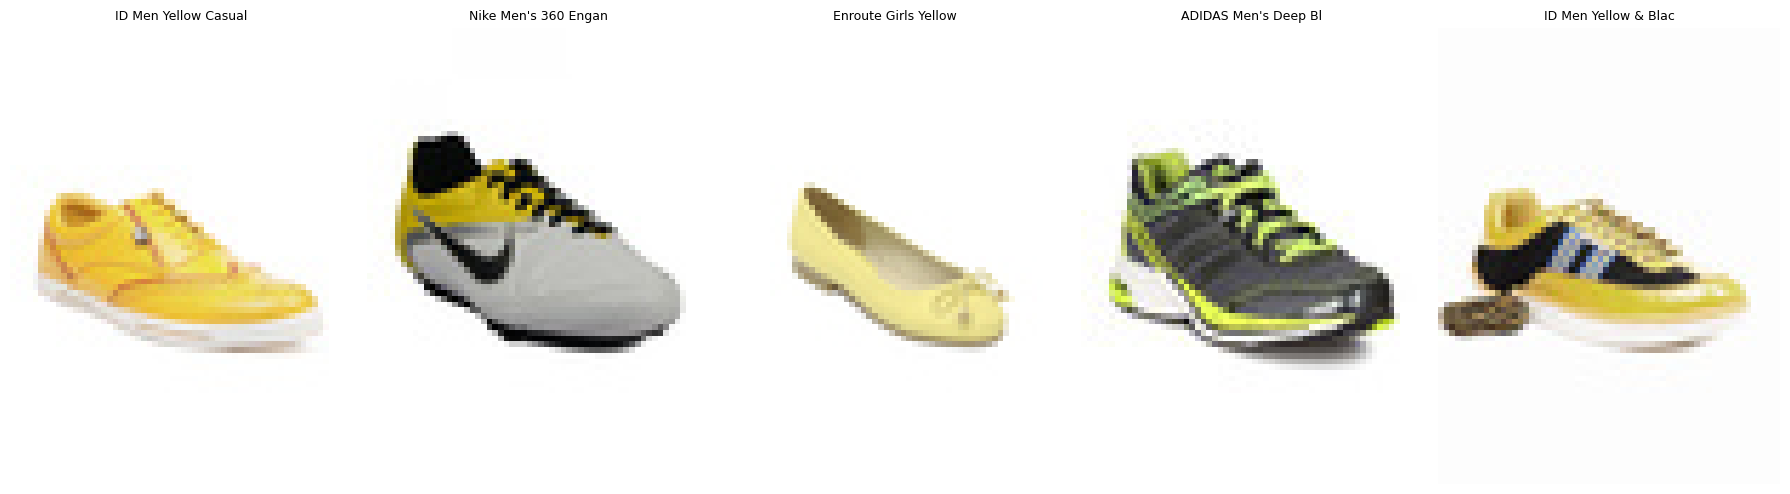

In [ ]:
result = search_products("yellow shoes")